In [ ]:
import numpy as np

x = np.array([[1,0,1,0], [1,0,1,1], [0,1,0,1]])
y = np.array([[1], [1], [0]])

def sigmoid_activation(x):
  return 1 / (1 + np.exp(-x))

def derivative_sigmoig(x):
  return x * (1 - x)

input_neurons = x.shape[1]
hidden_neurons = 3
output_neurons = 1

alpha = 0.1
epochs = 2000

wh = np.random.uniform(size=(input_neurons, hidden_neurons))
wout = np.random.uniform(size=(hidden_neurons, output_neurons))

bh = np.random.uniform(size=(1, hidden_neurons))
bout = np.random.uniform(size=(1, output_neurons))

for i in range(epochs):
# Feedforward

  hidden_layer_input = np.dot(x, wh) + bh
  hidden_activation = sigmoid_activation(hidden_layer_input)
  output_layer_input = np.dot(hidden_activation, wout) + bout
  output = sigmoid_activation(output_layer_input)

# Backpropagation
  loss_output = y - output
  slope_output_layer = derivative_sigmoig(output)
  delta_output = loss_output * slope_output_layer

  loss_hidden = delta_output.dot(wout.T)
  slope_hidden_layer = derivative_sigmoig(hidden_activation)
  delta_hidden = loss_hidden * slope_hidden_layer
# Update weights and blas
  wout = wout + hidden_activation.T.dot(delta_output) * alpha
  wh = wh + x.T.dot(delta_hidden) * alpha
  bout = bout + np.sum(delta_output, axis=0, keepdims=True) * alpha
  bh = bh + np.sum(delta_hidden,axis=0, keepdims=True) * alpha


In [ ]:
output

array([[0.95736447],
       [0.93733021],
       [0.09169808]])

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [4]:
(x_train,y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
x_train.shape

(60000, 28, 28)

In [8]:
x_test.shape

(10000, 28, 28)

In [9]:
import matplotlib.pyplot as plt

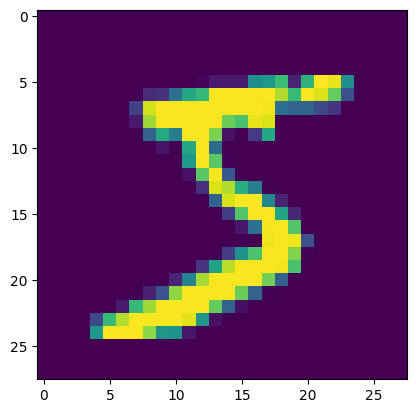

In [10]:
plt.imshow(x_train[0])

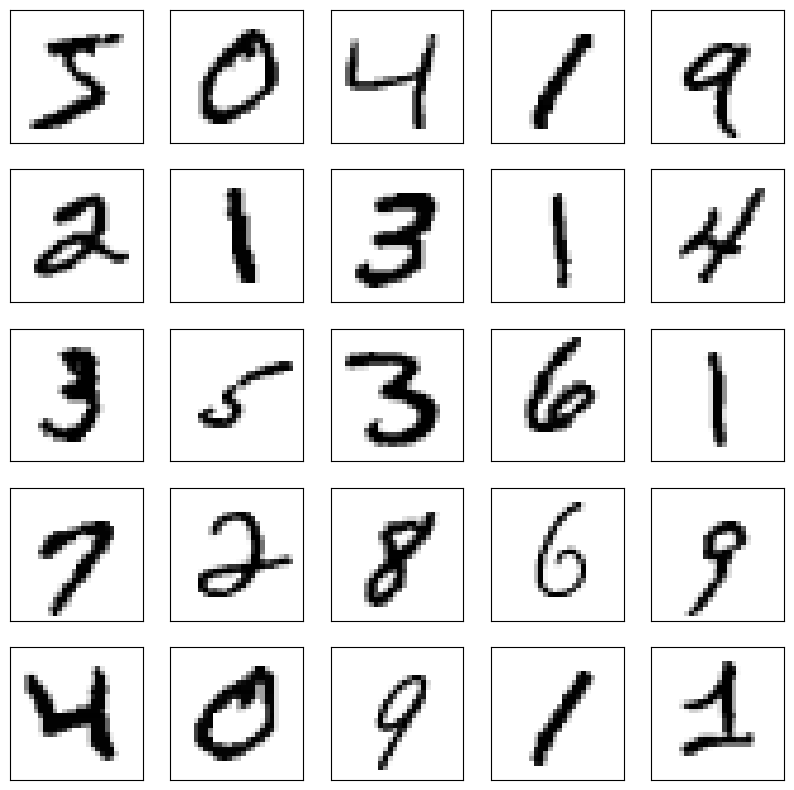

In [11]:
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_train[i], cmap=plt.cm.binary)
plt.show()

In [12]:
# Data Preprocessing - Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

In [13]:
model = Sequential([
    # Input layer
    Flatten(input_shape=(28,28)),
    # Hidden layer
    Dense(128, activation='relu'),
    Dense(100, activation="relu"),
    Dense(70, activation="relu"),
    Dense(50, activation="relu"),
    # Output layer
    Dense(10, activation='relu')
    # Dense(10, activation='softmax')

])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        12,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 70)             │         7,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         3,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,510 (486.37 KB)

 Trainable params: 124,510 (486.37 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer="adam",
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [16]:
model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8368 - loss: 0.4804 - val_accuracy: 0.8688 - val_loss: 0.3576
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8757 - loss: 0.3307 - val_accuracy: 0.8746 - val_loss: 0.3300
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8823 - loss: 0.3032 - val_accuracy: 0.8791 - val_loss: 0.3228
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8861 - loss: 0.2872 - val_accuracy: 0.8773 - val_loss: 0.3294
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8884 - loss: 0.2766 - val_accuracy: 0.8804 - val_loss: 0.3180


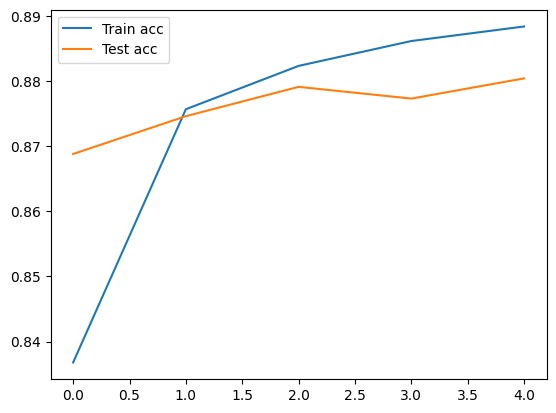

In [17]:
plt.plot(model.history.history["accuracy"], label="Train acc")
plt.plot(model.history.history["val_accuracy"], label="Test acc")
plt.legend()
plt.show()